In [49]:
import numpy as np
from scipy.io import wavfile
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# -------------------------------------------

import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
DATA_DIR = Path().resolve().parents[0] / "data"

sys.path.append(str(ROOT))
sys.path.append(str(DATA_DIR))

from embeddings.encoder import SpeakerEncoder

In [50]:
speaker_folders = sorted(DATA_DIR.glob("speaker*"))

speaker_audio = {}

for speaker_folder in speaker_folders:
    speaker_id = int(speaker_folder.name.replace("speaker", "")) # obtaining speaker name
    audio_files = sorted(speaker_folder.glob("*.wav")) # finding .wav files in folder

    for recording_id, audio_file in enumerate(audio_files):
        sr, audio = wavfile.read(audio_file)
        audio = audio.astype(np.float32) / 32768.0
        speaker_audio[(speaker_id, recording_id)] = (sr, audio)

In [51]:
encoder = SpeakerEncoder()

embeddings = []
labels = []

for (speaker, recording), (sr, audio) in speaker_audio.items():
    embedding = encoder.encode(audio, sr)
    embeddings.append(embedding)
    labels.append(speaker)

X = np.array(embeddings)

/Users/raiana/Codes/voice_detection/.venv/lib/python3.9/site-packages/speechbrain/utils/checkpoints.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(path, ma

In [52]:
thresholds = [0.3, 0.5, 0.7, 1.0]

for threshold in thresholds:
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=threshold,
        linkage="average",
        metric="cosine"
    )

    labels = clustering.fit_predict(X)

    print(f"Threshold: {threshold}")
    print(f"Clusters found: {len(set(labels))}")
    print(labels)
    print()

Threshold: 0.3
Clusters found: 8
[4 7 3 1 6 5 2 0]

Threshold: 0.5
Clusters found: 3
[1 1 2 2 0 0 0 0]

Threshold: 0.7
Clusters found: 2
[0 0 0 0 1 1 1 1]

Threshold: 1.0
Clusters found: 1
[0 0 0 0 0 0 0 0]



In [53]:
def plot_dendrogram(model):
    counts = np.zeros(model.children_.shape[0])

    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0

        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]

        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    dendrogram(linkage_matrix)

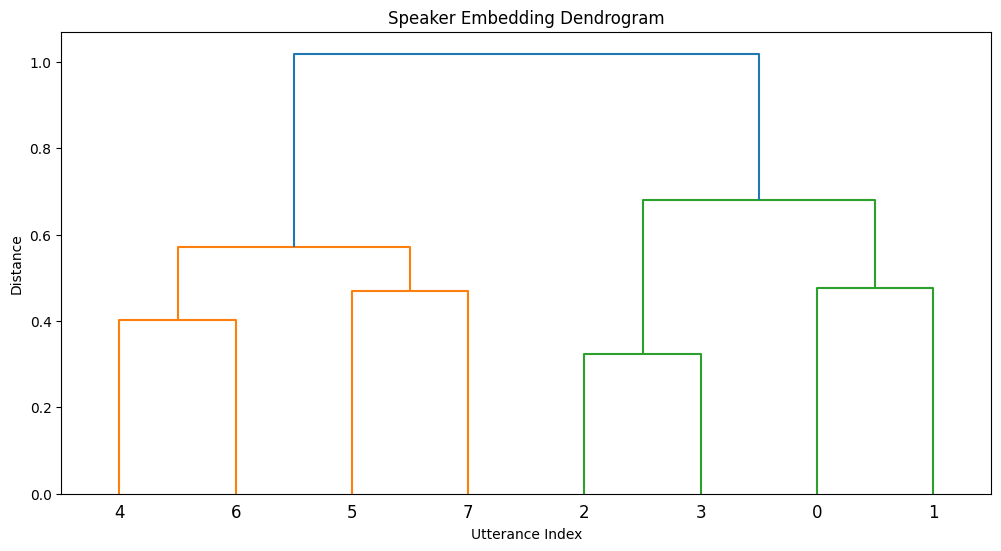

In [54]:
model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.5,
    linkage="complete", # use average if audio not clean
    metric="cosine"
)

model.fit(X)

plt.figure(figsize=(12, 6))

plot_dendrogram(model)

plt.title("Speaker Embedding Dendrogram")
plt.xlabel("Utterance Index")
plt.ylabel("Distance")

plt.show()